<a href="https://colab.research.google.com/github/aman16tayal/py-data-insights/blob/main/py_data_insights_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
df =pd.read_csv('/content/drive/MyDrive/iris.csv',header=None)
df.columns=['SL','SW','PL','PW','Target']
df

,SL,SW,PL,PW,Target
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,Iris-virginica
146,6.3,2.5,5.0,1.9,Iris-virginica
147,6.5,3.0,5.2,2.0,Iris-virginica
148,6.2,3.4,5.4,2.3,Iris-virginica


In [ ]:
df['Target'].value_counts()

,count
Target,
Iris-setosa,50
Iris-versicolor,50
Iris-virginica,50


In [ ]:
df.describe()

,SL,SW,PL,PW
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.054000,3.758667,1.198667
std,0.828066,0.433594,1.764420,0.763161
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


In [ ]:
# Check for missing values
df.isna().sum()

,0
SL,0
SW,0
PL,0
PW,0
Target,0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   SL      150 non-null    float64
 1   SW      150 non-null    float64
 2   PL      150 non-null    float64
 3   PW      150 non-null    float64
 4   Target  150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.0+ KB


<Axes: xlabel='Target', ylabel='count'>

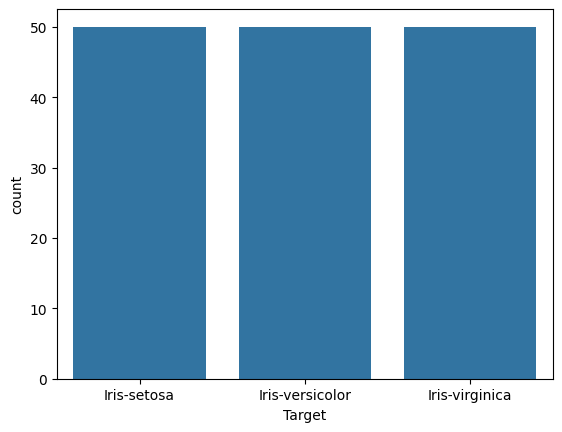

In [ ]:
import seaborn as sns
sns.countplot(x=df['Target'])

<Axes: >

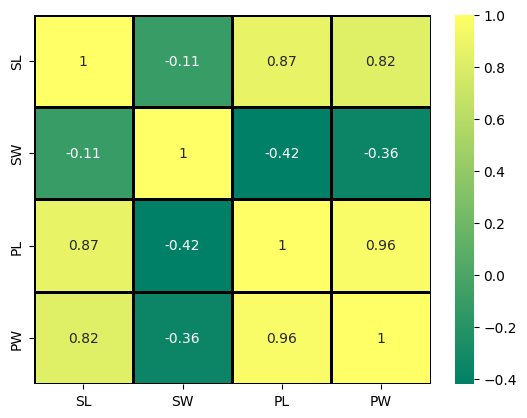

In [ ]:
cor=df[['SL','SW','PL','PW']].corr()
sns.heatmap(cor,annot=True, cmap='summer',linewidth=2,linecolor='black')

In [ ]:
df['Target'].value_counts()

,count
Target,
Iris-setosa,50
Iris-versicolor,50
Iris-virginica,50


In [ ]:
dict={'Iris-setosa':0,'Iris-versicolor':1,'Iris-virginica':2}
df['Target']=df['Target'].map(dict)
df

,SL,SW,PL,PW,Target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,2
146,6.3,2.5,5.0,1.9,2
147,6.5,3.0,5.2,2.0,2
148,6.2,3.4,5.4,2.3,2


In [ ]:
y=df['Target'] #target
x=df.drop(['Target'],axis=1) #input
print(x.shape)
print(y.shape)

(150, 4)
(150,)


In [ ]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.3,random_state=0)
print(x_train.shape)
print(x_test.shape)

(105, 4)
(45, 4)


In [ ]:
#   ML Model
from sklearn.linear_model import LogisticRegression
clf=LogisticRegression() # load model
clf.fit(x_train,y_train) # training
y_pred_train=clf.predict(x_train) # training data prediction
y_pred_test=clf.predict(x_test) # Testing prediction

In [ ]:
from sklearn.metrics import accuracy_score
train_acc=accuracy_score(y_train,y_pred_train)
test_acc=accuracy_score(y_test,y_pred_test)
print('Training Accuracy=',train_acc)
print('Testing Accuracy=',test_acc)

Training Accuracy= 0.9809523809523809
Testing Accuracy= 0.9777777777777777


In [ ]:
from sklearn.metrics import classification_report
cf=classification_report(y_test,y_pred_test)
print(cf)

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        16
           1       1.00      0.94      0.97        18
           2       0.92      1.00      0.96        11

    accuracy                           0.98        45
   macro avg       0.97      0.98      0.98        45
weighted avg       0.98      0.98      0.98        45



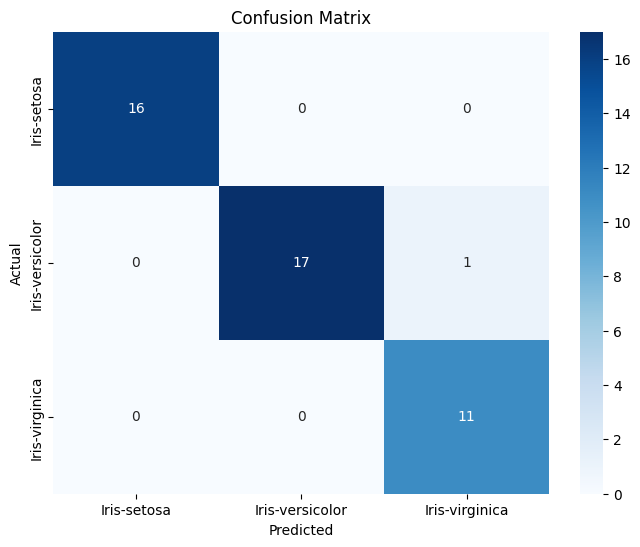

In [ ]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt

# Generate confusion matrix
cm = confusion_matrix(y_test, y_pred_test)

# Plotting
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=dict.keys(), yticklabels=dict.keys())
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()